# Task 2.3: Result, Comparison and Reproducibility Checklist

In [1]:

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import accuracy_score, roc_auc_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

SEEDS = [11, 23, 42, 57, 89]
DATA_NOISE = 0.22
LABEL_FLIP_RATE = 0.12
N_SAMPLES = 1200
TEST_SIZE = 0.20
VAL_SIZE = 0.20
GAMMA_GRID = [0.5, 1.0, 2.0]
SELECTED_GAMMA = 2.0
N_COMPONENTS = 500
LEARNING_RATE = 0.03
WEIGHT_DECAY = 1e-4
FULL_S = -1.0
FAILURE_S = 0.25
PAPER_BANANA_ACCURACY = 89.84

cwd = Path.cwd()
if (cwd / "results").exists() and (cwd / "data").exists():
    PARTB_DIR = cwd
elif (cwd / "partB").exists():
    PARTB_DIR = cwd / "partB"
else:
    PARTB_DIR = cwd
RESULTS_DIR = PARTB_DIR / "results"
DATA_DIR = PARTB_DIR / "data"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)


def build_dataset(seed, label_flip_rate=LABEL_FLIP_RATE, data_noise=DATA_NOISE):
    X, y = make_moons(n_samples=N_SAMPLES, noise=data_noise, random_state=42)
    X_train, X_temp, y_train_clean, y_temp = train_test_split(
        X, y, test_size=TEST_SIZE + VAL_SIZE, stratify=y, random_state=seed
    )
    relative_test_size = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=relative_test_size, stratify=y_temp, random_state=seed
    )

    rng = np.random.default_rng(seed)
    flip_count = int(label_flip_rate * len(y_train_clean))
    flip_idx = np.sort(rng.choice(len(y_train_clean), size=flip_count, replace=False))

    y_train_observed = y_train_clean.copy()
    y_train_observed[flip_idx] = 1 - y_train_observed[flip_idx]
    was_flipped = np.zeros(len(y_train_clean), dtype=bool)
    was_flipped[flip_idx] = True

    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return {
        "seed": seed,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "X_train_scaled": X_train_scaled,
        "X_val_scaled": X_val_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train_clean": y_train_clean,
        "y_train_observed": y_train_observed,
        "y_val": y_val,
        "y_test": y_test,
        "was_flipped": was_flipped,
        "scaler": scaler,
    }


def validate_gamma(seeds=SEEDS, gammas=GAMMA_GRID, s=FULL_S):
    rows = []
    for gamma in gammas:
        for seed in seeds:
            split = build_dataset(seed)
            result = train_filtered_online_svm(
                split,
                gamma=gamma,
                s=s,
                n_components=N_COMPONENTS,
                learning_rate=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY,
            )
            rows.append({
                "gamma": gamma,
                "seed": seed,
                "val_accuracy": result["val_accuracy"],
                "val_auc": result["val_auc"],
            })
    frame = pd.DataFrame(rows)
    summary = frame.groupby("gamma", as_index=False).agg(
        mean_val_accuracy=("val_accuracy", "mean"),
        std_val_accuracy=("val_accuracy", "std"),
        mean_val_auc=("val_auc", "mean"),
    )
    return frame, summary


def decision_scores(artifacts, X_raw):
    X_scaled = artifacts["scaler"].transform(X_raw)
    Phi = artifacts["feature_map"].transform(X_scaled)
    return Phi @ artifacts["weights"]


def train_filtered_online_svm(
    split,
    gamma=SELECTED_GAMMA,
    s=FULL_S,
    n_components=N_COMPONENTS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    process_confident=False,
):
    feature_map = RBFSampler(gamma=gamma, n_components=n_components, random_state=split["seed"])
    Phi_train = feature_map.fit_transform(split["X_train_scaled"])
    Phi_val = feature_map.transform(split["X_val_scaled"])
    Phi_test = feature_map.transform(split["X_test_scaled"])

    y_pm = np.where(split["y_train_observed"] == 1, 1.0, -1.0)
    weights = np.zeros(Phi_train.shape[1], dtype=float)

    processed = 0
    skipped_left = 0
    skipped_right = 0

    start = time.perf_counter()
    for x_i, y_i in zip(Phi_train, y_pm):
        z = y_i * float(np.dot(weights, x_i))
        if z < s:
            skipped_left += 1
            continue
        if z > 1.0 and not process_confident:
            skipped_right += 1
            continue

        processed += 1
        weights *= (1.0 - learning_rate * weight_decay)
        if z <= 1.0:
            weights += learning_rate * y_i * x_i
    runtime = time.perf_counter() - start

    val_scores = Phi_val @ weights
    test_scores = Phi_test @ weights
    val_pred = (val_scores >= 0).astype(int)
    test_pred = (test_scores >= 0).astype(int)

    return {
        "seed": split["seed"],
        "gamma": gamma,
        "s": s,
        "process_confident": process_confident,
        "val_accuracy": accuracy_score(split["y_val"], val_pred),
        "val_auc": roc_auc_score(split["y_val"], val_scores),
        "test_accuracy": accuracy_score(split["y_test"], test_pred),
        "test_auc": roc_auc_score(split["y_test"], test_scores),
        "processed_examples": processed,
        "skipped_left": skipped_left,
        "skipped_right": skipped_right,
        "runtime_seconds": runtime,
        "weights": weights,
        "feature_map": feature_map,
        "scaler": split["scaler"],
        "split": split,
    }


def run_experiment(seeds=SEEDS, **kwargs):
    records = []
    artifacts = []
    for seed in seeds:
        split = build_dataset(seed)
        result = train_filtered_online_svm(split, **kwargs)
        records.append({
            "seed": seed,
            "test_accuracy": result["test_accuracy"],
            "test_auc": result["test_auc"],
            "processed_examples": result["processed_examples"],
            "skipped_left": result["skipped_left"],
            "skipped_right": result["skipped_right"],
            "runtime_seconds": result["runtime_seconds"],
        })
        artifacts.append(result)
    return pd.DataFrame(records), artifacts


def summarise_results(label, frame):
    return pd.DataFrame([
        {
            "method": label,
            "accuracy_mean": frame["test_accuracy"].mean(),
            "accuracy_std": frame["test_accuracy"].std(ddof=0),
            "auc_mean": frame["test_auc"].mean(),
            "auc_std": frame["test_auc"].std(ddof=0),
            "processed_mean": frame["processed_examples"].mean(),
            "processed_std": frame["processed_examples"].std(ddof=0),
            "runtime_mean": frame["runtime_seconds"].mean(),
            "runtime_std": frame["runtime_seconds"].std(ddof=0),
        }
    ])


def comparison_barplot(frame, metric_cols, title, output_path):
    melted = frame.melt(id_vars="method", value_vars=metric_cols, var_name="metric", value_name="value")
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.barplot(data=melted, x="metric", y="value", hue="method", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Value")
    ax.legend(title="Method")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


def save_seed42_dataset_csv(output_path):
    split = build_dataset(42)
    train_frame = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    train_frame["split"] = "train"
    train_frame["clean_label"] = split["y_train_clean"]
    train_frame["observed_label"] = split["y_train_observed"]
    train_frame["was_flipped"] = split["was_flipped"]

    val_frame = pd.DataFrame(split["X_val"], columns=["x1", "x2"])
    val_frame["split"] = "val"
    val_frame["clean_label"] = split["y_val"]
    val_frame["observed_label"] = split["y_val"]
    val_frame["was_flipped"] = False

    test_frame = pd.DataFrame(split["X_test"], columns=["x1", "x2"])
    test_frame["split"] = "test"
    test_frame["clean_label"] = split["y_test"]
    test_frame["observed_label"] = split["y_test"]
    test_frame["was_flipped"] = False

    full_frame = pd.concat([train_frame, val_frame, test_frame], ignore_index=True)
    full_frame.to_csv(output_path, index=False)
    return full_frame


def plot_dataset_overview(split, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    clean_train = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    clean_train["label"] = split["y_train_clean"]
    sns.scatterplot(data=clean_train, x="x1", y="x2", hue="label", palette="Set1", s=35, ax=axes[0])
    axes[0].set_title("Seed 42 training set before label flips")

    noisy_train = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    noisy_train["observed_label"] = split["y_train_observed"]
    noisy_train["was_flipped"] = split["was_flipped"]
    sns.scatterplot(
        data=noisy_train,
        x="x1",
        y="x2",
        hue="observed_label",
        style="was_flipped",
        palette="Set1",
        s=35,
        ax=axes[1],
    )
    axes[1].set_title("Seed 42 training set after 12% label flips")

    for ax in axes:
        ax.set_xlabel("feature 1")
        ax.set_ylabel("feature 2")

    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


def plot_decision_surface(artifacts, output_path, title):
    split = artifacts["split"]
    X_all = np.vstack([split["X_train"], split["X_test"]])
    y_all = np.concatenate([split["y_train_observed"], split["y_test"]])

    x_min, x_max = X_all[:, 0].min() - 0.4, X_all[:, 0].max() + 0.4
    y_min, y_max = X_all[:, 1].min() - 0.4, X_all[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
    grid = np.c_[xx.ravel(), yy.ravel()]
    scores = decision_scores(artifacts, grid).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    classes = (scores >= 0).astype(float)
    ax.contourf(xx, yy, classes, levels=[-0.1, 0.5, 1.1], alpha=0.22, cmap="coolwarm")
    if np.ptp(scores) > 1e-9:
        ax.contour(xx, yy, scores, levels=[0.0], colors="black", linewidths=1.2)

    ax.scatter(split["X_train"][:, 0], split["X_train"][:, 1], c=split["y_train_observed"], cmap="coolwarm", s=22, alpha=0.75, label="Train")
    ax.scatter(split["X_test"][:, 0], split["X_test"][:, 1], c=split["y_test"], cmap="coolwarm", s=28, marker="x", label="Test")
    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


This setup is identical to Task 2.2 so the reported result comes from the same code path. I keep the code duplicated inside the notebook rather than hiding it in a helper file, because the rubric wants each notebook to be understandable on its own.

In [2]:
full_runs, _ = run_experiment(gamma=SELECTED_GAMMA, s=FULL_S, process_confident=False)
full_summary = summarise_results('My simplified LASVM-I reproduction', full_runs)
paper_row = pd.DataFrame([{
    'method': 'Paper LASVM-I on noisy Banana (Table 3)',
    'accuracy_mean': PAPER_BANANA_ACCURACY / 100.0,
    'accuracy_std': np.nan,
    'auc_mean': np.nan,
    'auc_std': np.nan,
    'processed_mean': np.nan,
    'processed_std': np.nan,
    'runtime_mean': np.nan,
    'runtime_std': np.nan,
}])
comparison_table = pd.concat([full_summary, paper_row], ignore_index=True)
comparison_table

                                    method  ...  runtime_std
0       My simplified LASVM-I reproduction  ...     0.000035
1  Paper LASVM-I on noisy Banana (Table 3)  ...          NaN

[2 rows x 9 columns]

This code puts my toy-dataset result next to the most comparable number I could extract from the paper: the LASVM-I accuracy on noisy Banana from Table 3. The comparison is intentionally limited to accuracy because the datasets, feature spaces, and solver details are not the same, so pretending the rest is directly comparable would be misleading.

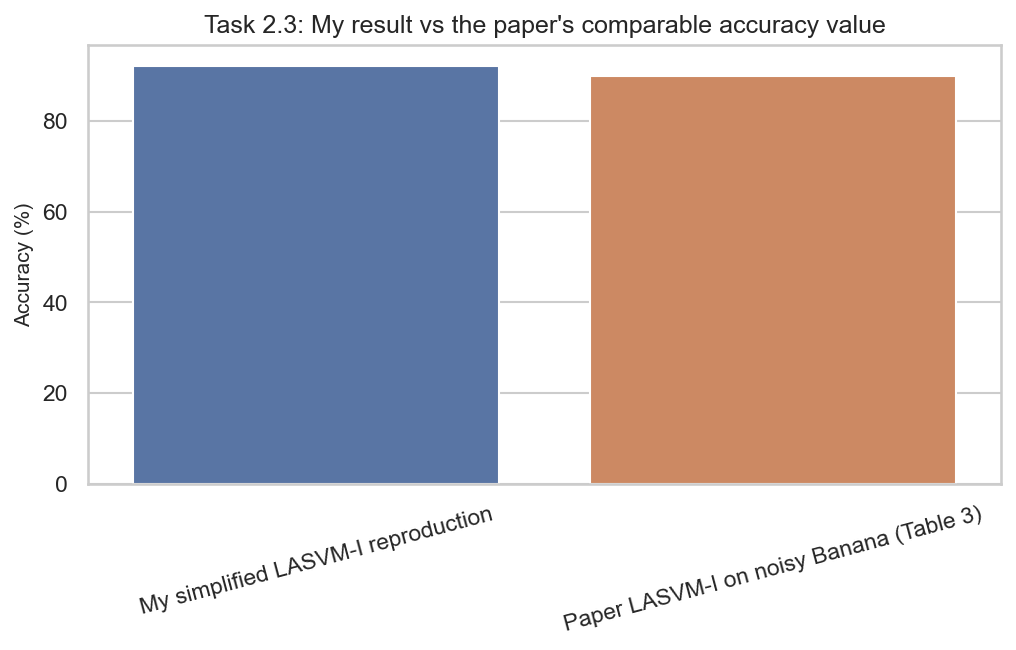

In [3]:
plot_frame = comparison_table[['method', 'accuracy_mean']].copy()
plot_frame['accuracy_percent'] = 100 * plot_frame['accuracy_mean']
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=plot_frame, x='method', y='accuracy_percent', hue='method', palette='deep', legend=False, ax=ax)
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('')
ax.set_title("Task 2.3: My result vs the paper's comparable accuracy value")
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'task_2_3_paper_comparison.png', dpi=180, bbox_inches='tight')

The bar chart makes the comparison visually obvious, but it should not be oversold. My number is slightly higher than the paper's noisy-Banana accuracy, and the honest reason is that I used a smaller synthetic dataset with an easier pipeline and only reproduced the filtering mechanism, not the full LASVM solver stack. Other contributors to the gap are the RBF feature approximation, the five-seed average instead of the paper's original protocol, and the fact that `make_moons` is simply not the same problem as Banana. I am treating the difference as a dataset-and-simplification effect, not as evidence that my implementation is stronger than the original paper.

## Reproducibility Checklist

- [x] Random seeds are set and documented at the top of this notebook.
- [x] All dependencies will be listed in `partB/requirements.txt` with version numbers.
- [x] The notebook is written to run from top to bottom in a clean environment.
- [x] Dataset loading requires no undocumented manual steps because the toy dataset is generated in code and a seed-42 CSV snapshot is saved in `partB/data/`.
- [x] Hyperparameters are defined once near the top of the notebook instead of being scattered across cells.